In [ ]:
# !uv pip install numpy matplotlib scipy pywavelet tqdm pyocclient

<a target="_blank" href="https://colab.research.google.com/github/ANDA-NI-2026/ANDA-Day5-Spectral-Analysis/blob/main/02_power_spectra_and_time_resolved_frequency_analysis/02_exercises.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [ ]:
# When running in Google Colab, uncomment the next line to download the spectral library
# !wget -O spectral.py "https://uni-bonn.sciebo.de/s/brJ85pcWgyNbxcs/download"

# Power Spectra and Time-Frequency Analysis

Neural recordings such as the local field potential are rich in oscillatory structure, and the questions we usually ask about them, such as which rhythms are present, how strong they are, and when they appear, are often best answered in the frequency domain. This notebook introduces the tools for calculating the frequency spectrum for signals, starting from the Fourier transform and the power spectral density, and see how sampling rate and recording duration affect frequency resolution.

Because the Fourier transform assumes a signal's frequency content is stationary, it cannot say *when* a rhythm occurs, which would be a serious limitation when we are interested in changes in neural activity around events like stimulus onset. You will therefore learn how to use the Morlet wavelet transform to get a time-resolved frequency spectrum and how to determine which parts of the spectrum are affected by edge-artifacts.

## Setup

### Import Libraries

Run the cell below to import the libraries used in this notebook.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import spectral
import scipy
from pathlib import Path
import sys
from tqdm import tqdm
import os

### Utility Functions

Run the cell below to define utility functions used throughout this notebook.

In [3]:
class utils:
    @staticmethod
    def generate_signal(t0: float, t1: float, time_step: float, frequency: float, amp: float, amp_offs: float):
        t = np.arange(t0, t1, time_step)
        signal = amp_offs + amp * np.sin(2* np.pi * frequency * t)

        return signal

    @staticmethod
    def plot_fft_amp_spectrum(fft_amp_spectrum, frequencies, xlabel: str = 'Frequency (Hz)', ylabel: str = 'Amplitude (a.u.)', title: str = 'FFT Amplitude Spectrum'):
        plt.figure(figsize=(9,3))
        plt.plot(frequencies, fft_amp_spectrum)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.title(title)
        plt.tight_layout()

    @staticmethod
    def plot_power_spectrum(psd, 
                            frequencies, 
                            xlabel: str = 'Frequency (Hz)', 
                            ylabel: str = 'PSD (signal² / Hz)', 
                            title: str = 'Power Spectrum', 
                            apply_grid: bool = False, 
                            xscale: str = 'linear', 
                            yscale: str = 'linear',  
                            label: str | None = None):
        plt.plot(frequencies, psd, label = label)
        plt.xscale(xscale)
        plt.yscale(yscale)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.title(title)
        if apply_grid:
            plt.grid(True, alpha = 0.3)
        else:
            plt.grid(False)
        plt.tight_layout()

    @staticmethod
    def plot_signal(sig, time_vec):
        """Makes plot of signal"""
        plt.figure()
        plt.plot(time_vec,sig)
        plt.title('Signal')
        plt.xlabel('Time')
        plt.ylabel('Amplitude')

### Download Data

Run the cell below to download the datasets used in this notebook.

In [4]:
import owncloud

Path('../data').mkdir(exist_ok=True, parents=True)

oc = owncloud.Client.from_public_link('https://uni-bonn.sciebo.de/s/NPyTrnkZPLWH9Yz', folder_password='ibots')
oc.get_file('/', '../data/spectral_dataset.mat')

/Users/didi/Desktop/ANDA_NI_2026/repos/ANDA-Day5-Spectral-Analysis/.pixi/envs/default/lib/python3.13/site-packages/owncloud/owncloud.py:602: SyntaxWarning: invalid escape sequence '\*'
  :param \*\*kwargs: optional arguments that ``put_file`` accepts
/Users/didi/Desktop/ANDA_NI_2026/repos/ANDA-Day5-Spectral-Analysis/.pixi/envs/default/lib/python3.13/site-packages/owncloud/owncloud.py:636: SyntaxWarning: invalid escape sequence '\*'
  :param \*\*kwargs: optional arguments that ``put_file`` accepts
/Users/didi/Desktop/ANDA_NI_2026/repos/ANDA-Day5-Spectral-Analysis/.pixi/envs/default/lib/python3.13/site-packages/owncloud/owncloud.py:1746: SyntaxWarning: invalid escape sequence '\*'
  :param \*\*kwargs: optional arguments that ``requests.Request.request`` accepts
/Users/didi/Desktop/ANDA_NI_2026/repos/ANDA-Day5-Spectral-Analysis/.pixi/envs/default/lib/python3.13/site-packages/owncloud/owncloud.py:1766: SyntaxWarning: invalid escape sequence '\*'
  :param \*\*kwargs: optional arguments that

True

## Signals, Sampling, and the Discrete Fourier Transform

A recorded neural signal is a sequence of voltage samples taken at a regular interval $\Delta t$, called the sampling period. The sampling rate $f_s = 1/\Delta t$ determines the highest frequency that can faithfully be represented: the Nyquist frequency $f_{\text{Nyq}} = f_s / 2$. Any signal energy above the Nyquist frequency folds back into lower frequencies, a phenomenon called aliasing. The total recording duration $T = N \Delta t$ determines the frequency resolution $\Delta f = 1/T$: longer recordings allow higher frequency resolution.

The discrete Fourier transform (DFT) decomposes a real-valued signal of $N$ samples into $N/2 + 1$ complex coefficients, each representing a cosine and sine component at a specific frequency. Before interpreting any spectrum it is essential to construct the correct frequency axis. Given $N$ time bins of duration $\Delta t$, there are $N_{\text{fft}} = N//2 + 1$ frequency bins.

In this section, you will calculate and plot the discrete Fourier transform (DFT) for different toy signals and study how signal properties such as peak frequency, duration, and DC offset are observed in the calculated spectrum.

| Code | Description |
| --- | --- |
| `n_bins = int(np.ceil((t1 - t0) / time_step))` | Number of time bins |
| `signal = utils.generate_signal(t0, t1, time_step, frequency, amp, amp_offset)` | Generate a sine wave |
| `fft_amp_spectrum = np.abs(np.fft.rfft(signal))` | One-sided FFT amplitude spectrum |
| `n_fft = len(fft_amp_spectrum)` | Number of frequency bins |
| `delta_freq = 1.0 / (n_bins * time_step)` | Frequency resolution |
| `frequencies = delta_freq * np.arange(n_fft)` | Frequency axis; the frequencies for which spectrum is calculated |
| `utils.plot_fft_amp_spectrum(fft_amp_spectrum, frequencies)` | Plot the amplitude spectrum |
| `1 / time_step` | Sampling frequency $f_s$ |
| `1 / time_step / 2` | Nyquist frequency $f_{\text{Nyq}}$ |

---

#### **Exercises**

Run the cell below to create a sine wave at `frequency = 40` Hz with amplitude `3.2` and DC offset `2.1`, sampled at `time_step = 0.005` s lasting from `t0 = 0` to `t1 = 3` s.

In [5]:
t0 = 0.0; t1 = 3.0; time_step = 0.005
n_bins = int(np.ceil((t1-t0)/time_step))
frequency = 40.0
amp = 3.2; amp_offset = 2.1

signal = utils.generate_signal(t0, t1, time_step, frequency, amp, amp_offset)

**Example**: Compute and plot the FFT amplitude spectrum.

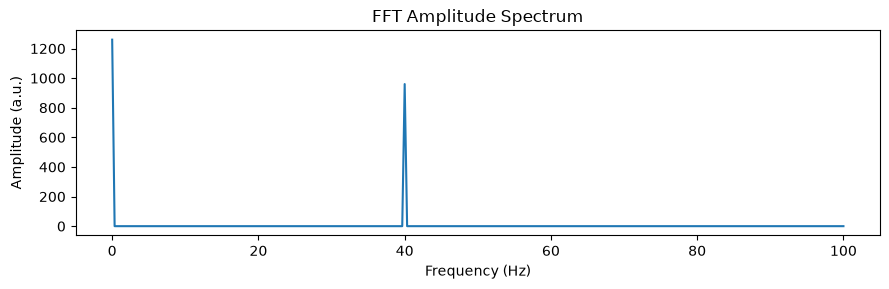

In [6]:
fft_amp_spectrum = np.abs(np.fft.rfft(signal)) # calculate the Fourier amplitude spectrum
n_fft = len(fft_amp_spectrum)
delta_freq = 1.0 / (n_bins * time_step) # calculate the frequency resolution
frequencies = delta_freq * np.arange(n_fft) # get the frequencies for which the Fourier amplitude is calculated (the frequency axis of the plot)


utils.plot_fft_amp_spectrum(fft_amp_spectrum, frequencies)

Run the cell below to generate a new sine wave signal with `frequency = 80 Hz`. 

In [7]:
frequency = 80.0

signal = utils.generate_signal(t0, t1, time_step, frequency, amp, amp_offset)

**Exercise**: Compute and plot the FFT amplitude spectrum for the new signal and verify that the amplitude peak shifts to 80 Hz.

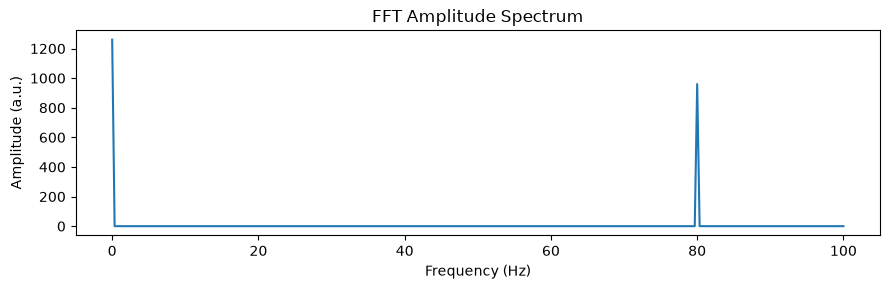

In [8]:
fft_amp_spectrum = np.abs(np.fft.rfft(signal)) # calculate the Fourier amplitude spectrum
n_fft = len(fft_amp_spectrum)
delta_freq = 1.0 / (n_bins * time_step) # calculate the frequency resolution
frequencies = delta_freq * np.arange(n_fft) # get the frequencies for which the Fourier amplitude is calculated (the frequency axis of the plot)


utils.plot_fft_amp_spectrum(fft_amp_spectrum, frequencies)

Run the cell below to generate a new sine wave signal with the `frequency` back at `40 Hz` and the `amp_offs = 0` (i.e. the DC offset removed).

In [9]:
frequency = 40
amp_offset = 0.0

signal = utils.generate_signal(t0, t1, time_step, frequency, amp, amp_offset)

**Exercise**: Compute and plot the FFT amplitude spectrum for the new signal. Compare to the plot in the example and observe the change at the leftmost bin `frequency = 0`. What does the zero-frequency bin represent?

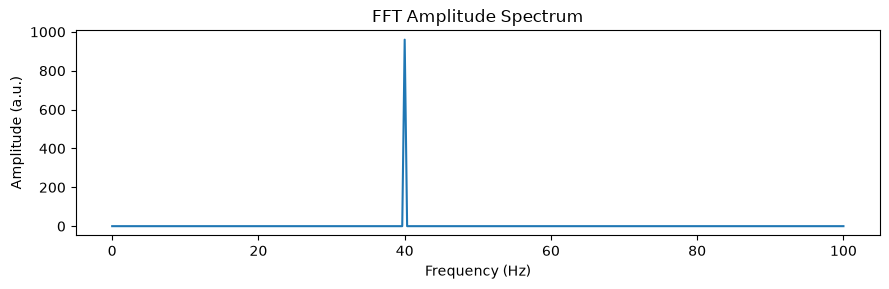

In [10]:
fft_amp_spectrum = np.abs(np.fft.rfft(signal)) # calculate the Fourier amplitude spectrum
n_fft = len(fft_amp_spectrum)
delta_freq = 1.0 / (n_bins * time_step) # calculate the frequency resolution
frequencies = delta_freq * np.arange(n_fft) # get the frequencies for which the Fourier amplitude is calculated (the frequency axis of the plot)


utils.plot_fft_amp_spectrum(fft_amp_spectrum, frequencies)

**Exercise**: What is the sampling frequency (in Hz) of all the signals generated in the previous exercises? **Hint**: See code reference table.

In [12]:
time_step


0.005

**Exercise**: What is the Nyquist frequency for this sample rate?

In [13]:
time_step / 2

0.0025

Run the cell below to generate a new 40 Hz sine wave signal where the duration (you can think of it as the recording period) has been increased to `t1 = 6.0` s.

In [14]:
frequency = 40
amp_offset = 0.0
t1 = 6.0
n_bins = int(np.ceil((t1-t0)/time_step))

signal = utils.generate_signal(t0, t1, time_step, frequency, amp, amp_offset)

**Exercise**: Compute and plot the FFT amplitude spectrum for the new signal. How does the increased signal duration affect the frequency resolution of the Fourier spectrum? **Hint**: Compare the peak of the Fourier amplitude plot for this signal to the plots above - is the peak narrower or broader?

Didi: it has almost doubled vs previous simulations

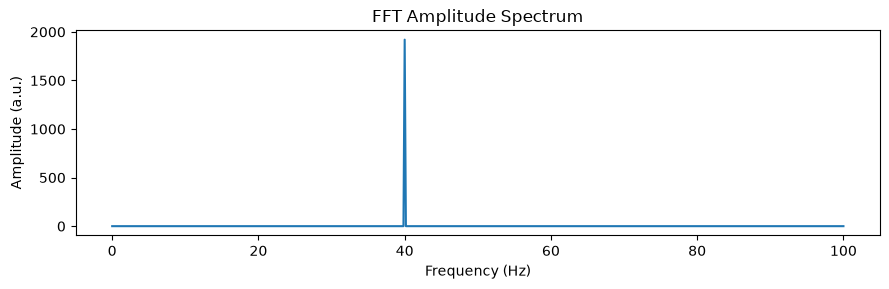

In [15]:
fft_amp_spectrum = np.abs(np.fft.rfft(signal)) # calculate the Fourier amplitude spectrum
n_fft = len(fft_amp_spectrum)
delta_freq = 1.0 / (n_bins * time_step) # calculate the frequency resolution
frequencies = delta_freq * np.arange(n_fft) # get the frequencies for which the Fourier amplitude is calculated (the frequency axis of the plot)


utils.plot_fft_amp_spectrum(fft_amp_spectrum, frequencies)

Run the cell below to generate a new sine wave signal with the `frequency = 40 Hz` and the `amp_offs = 2.1` and with Gaussian noise added to the signal.

In [16]:
frequency = 40
amp_offset = 2.1

rng = np.random.default_rng(0)
signal = utils.generate_signal(t0, t1, time_step, frequency, amp, amp_offset) + 6 * rng.normal(0, 2.0, n_bins)

**Exercise**: Compute and plot the FFT amplitude spectrum for the new signal. Is the peak at 40 Hz still visible?

Didi: although visible, it is now unclear if it is a significant spike or just noise

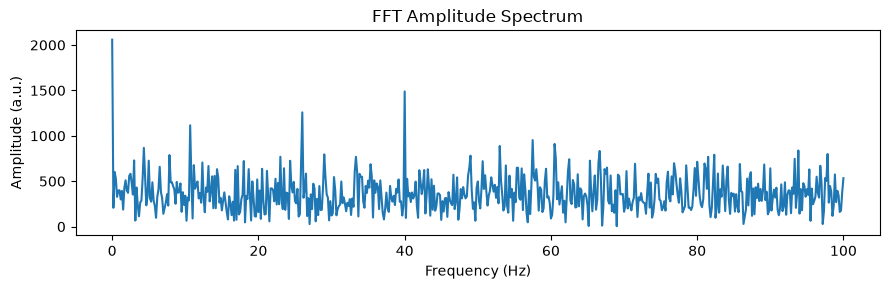

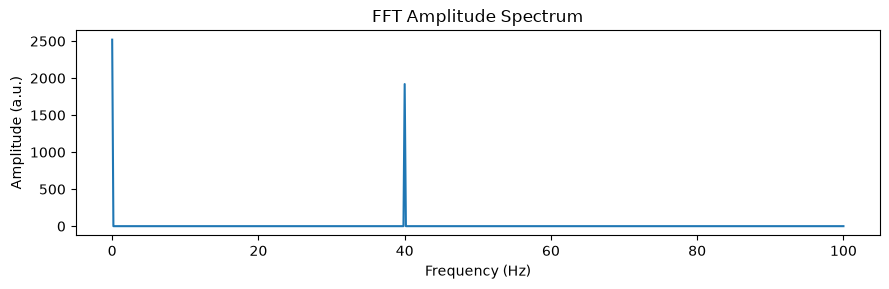

In [18]:
fft_amp_spectrum = np.abs(np.fft.rfft(signal)) # calculate the Fourier amplitude spectrum
n_fft = len(fft_amp_spectrum)
delta_freq = 1.0 / (n_bins * time_step) # calculate the frequency resolution
frequencies = delta_freq * np.arange(n_fft) # get the frequencies for which the Fourier amplitude is calculated (the frequency axis of the plot)


utils.plot_fft_amp_spectrum(fft_amp_spectrum, frequencies)

# No ausian noise
frequency = 40
amp_offset = 2.1

rng = np.random.default_rng(0)
signal = utils.generate_signal(t0, t1, time_step, frequency, amp, amp_offset)
fft_amp_spectrum = np.abs(np.fft.rfft(signal)) # calculate the Fourier amplitude spectrum
n_fft = len(fft_amp_spectrum)
delta_freq = 1.0 / (n_bins * time_step) # calculate the frequency resolution
frequencies = delta_freq * np.arange(n_fft) # get the frequencies for which the Fourier amplitude is calculated (the frequency axis of the plot)


utils.plot_fft_amp_spectrum(fft_amp_spectrum, frequencies)



## Power Spectral Density, Averaged Power Spectra, and Parseval's Theorem

The power spectral density (PSD) expresses how the variance of a signal is distributed across frequencies. Unlike the raw FFT magnitude computed in the previous section, the PSD is normalized so that its integral over all frequencies equals the signal variance: $\text{var}(s) = \int_0^{f_{\text{Nyq}}} \text{PSD}(f)\, df$. This is Parseval's theorem, and it is the single most useful sanity check when computing spectra. The function `spectral.power(signal, time_step)` implements this normalization. It returns the PSD in units of $[\text{signal}^2 / \text{Hz}]$.

A further consequence of Parseval's theorem relates the DC bin to the signal mean: $\sqrt{\text{PSD}[0] \cdot \Delta f} = \bar{s}$. Verifying both this relation and the relationship between the variance of the signal and the integral of the power spectrum is the most direct way to confirm that a spectrum has been computed and normalized correctly.

To reduce noise in a power spectrum, it is common to average over multiple, independent spectral estimates. A single power spectrum estimated from a long recording has high frequency resolution but also high variance.

The simplest approach is Bartlett's method: divide the recording into $K$ non-overlapping chunks of equal length, compute the PSD of each, and take the mean. Averaging $K$ spectra reduces the variance by a factor $K$ at the cost of a $K$-fold decrease in frequency resolution. The function `spectral.power_average(signal, time_step, n_average)` implements this using `n_average` chunks.

In practice, the choice of `n_average` balances noise reduction against spectral resolution. If the feature of interest is a narrow peak, the chunk length must be long enough so that the frequency resolution remains finer than the peak width. A useful rule of thumb: the chunk length should be at least ten periods of the lowest frequency of interest.

| Code | Description |
| --- | --- |
| `psd, frequencies, df = spectral.power(signal, time_step)` | Calculate PSD for signal at frequency axis `frequencies` |
| `psd_avg, frequencies_avg, df_avg = spectral.power_average(signal, time_step, n_average=n_win_average)` | Calculate window-averaged PSD for signal |
| `utils.plot_power_spectrum(psd_avg, frequencies_avg, yscale='log', label=...)` | Plot averaged PSD on log y-axis |
| `np.allclose(psd_raw, psd_avg1)` | Check two PSDs are numerically identical |
| `utils.plot_power_spectrum(psd, frequencies)` | Plot the power spectrum |
| `np.var(signal)` | Calculate signal variance |
| `np.sum(psd[1:]) * delta_freq` | Integral of PSD over positive frequencies (equals signal variance) |
| `np.mean(signal)` | Calculate signal mean |
| `np.sqrt(psd[0] * delta_freq)` | Amplitude from DC bin (equals signal mean) |

---

Run the cell below to create a sine wave at `frequency = 40` Hz with Gaussian noise.

In [21]:
t0 = 0.0; t1 = 3.0; time_step = 0.005
n_bins = int(np.ceil((t1-t0)/time_step))
frequency = 40.0
amp = 3.2; amp_offset = 2.1
rng = np.random.default_rng(0)

signal = utils.generate_signal(t0, t1, time_step, frequency, amp, amp_offset) + 2 * rng.normal(0, 2, n_bins)

**Example**: Calculate the power spectrum for the signal with and without averaging the spectrum over 5 windows (`n_win_average=5`). Plot the two power spectra together to compare them. What happens to the noise when you average over windows?

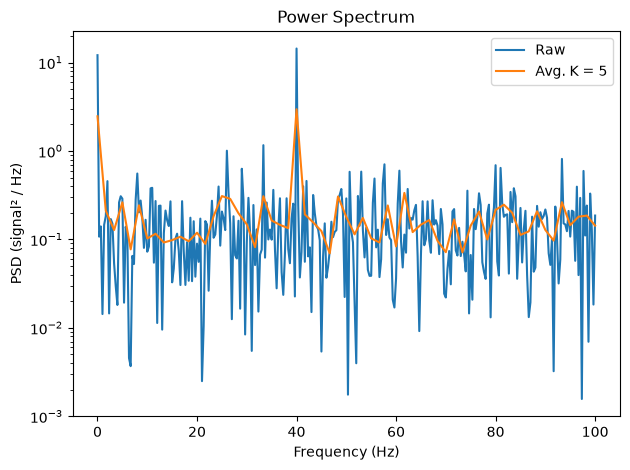

In [22]:
psd_raw, frequencies_raw, df_raw = spectral.power(signal, time_step)

n_win_average = 5
psd_avg, frequencies_avg, df_avg = spectral.power_average(signal, time_step, n_average=n_win_average)

utils.plot_power_spectrum(psd_raw, frequencies_raw, yscale = 'log', label = 'Raw')
utils.plot_power_spectrum(psd_avg, frequencies_avg, yscale = 'log', label = f'Avg. K = {n_win_average}')
plt.legend();

**Exercise**: Increase `n_win_average` to `20`. How does the averaged spectrum change compared to `n_win_average=5`? What happens to the frequency resolution?

Diid: resolution decreased signfiicantly

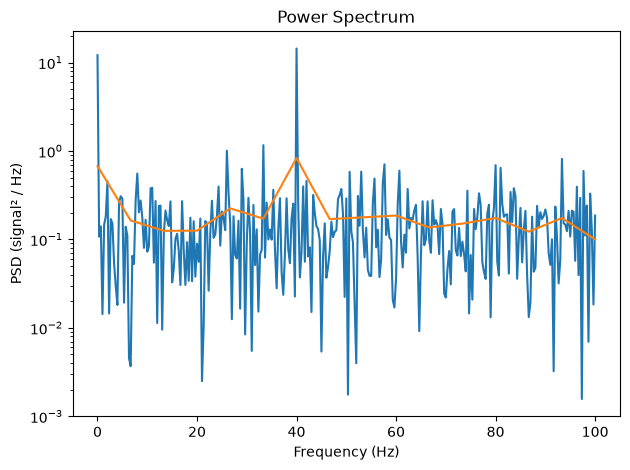

In [23]:
n_win_average = 20
psd_avg, frequencies_avg, df_avg = spectral.power_average(signal, time_step, n_average=n_win_average)

utils.plot_power_spectrum(psd_raw, frequencies_raw, yscale = 'log', label = 'Raw')
utils.plot_power_spectrum(psd_avg, frequencies_avg, yscale = 'log', label = f'Avg. K = {n_win_average}')

**Exercise**: Set `n_win_average=1`, calculate the power spectrum using `spectral.power_average`, and verify that the result is identical to the raw, non-averaged PSD. You can do that by plotting the raw power spectrum together with the power spectrum where you average over a single window or by calculating `np.allclose(psd_raw, psd_avg1)`.

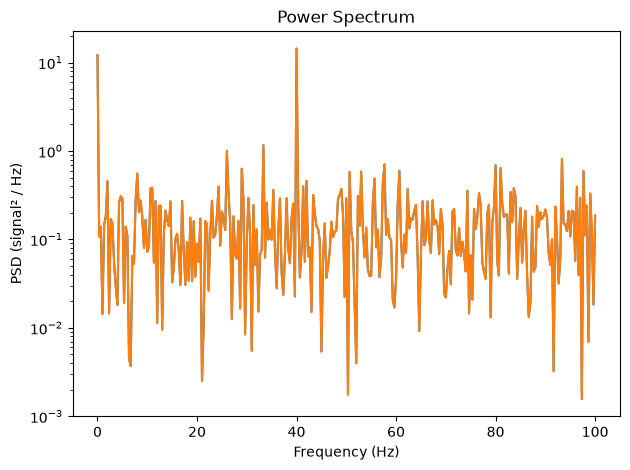

In [24]:
n_win_average = 1
psd_avg, frequencies_avg, df_avg = spectral.power_average(signal, time_step, n_average=n_win_average)

utils.plot_power_spectrum(psd_raw, frequencies_raw, yscale = 'log', label = 'Raw')
utils.plot_power_spectrum(psd_avg, frequencies_avg, yscale = 'log', label = f'Avg. K = {n_win_average}')

In [25]:
np.allclose(psd_raw, psd_avg)

True

Run the cell below to create a sine wave at `frequency = 40` Hz.

In [26]:
frequency = 40.0
amp_offset = 2.1

signal = utils.generate_signal(t0, t1, time_step, frequency, amp, amp_offset)
psd, frequencies, delta_freq = spectral.power(signal, time_step)

**Exercise**: Verify Parseval's theorem for the signal generated above using the relationship between the variance of the signal and the integral of the computed power spectrum. In other words, calculate and print `np.var(signal)` and `np.sum(psd[1:]) * delta_freq`. Do they match?

In [28]:
print(np.var(signal))
print("-"*40)
print(np.sum(psd[1:]) * delta_freq)
print("close enough :)")


5.120000000000003
----------------------------------------
5.120000000000002
close enough :)


**Exercise**: Verify Parseval's theorem using the relationship between the mean of the signal and the DC bin (the zeroth frequency) of the power spectrum. Do they match?

In [30]:
print(np.sqrt(psd[0] * delta_freq))
print("-"*40)
print(np.mean(signal))
print("close enough :D")

2.100000000000014
----------------------------------------
2.1000000000000143
close enough :D


Run the cell below to create a signal that is the sum of two sines at 40 and 80 Hz with amplitudes 1 and 2 respectively (no noise, no DC). 

In [31]:
amp1 = 1
amp2 = 2

frequency1 = 40.0
frequency2 = 80.0
amp_offset = 0.0

signal1 = utils.generate_signal(t0, t1, time_step, frequency1, amp1, amp_offset)
signal2 = utils.generate_signal(t0, t1, time_step, frequency2, amp2, amp_offset)

signal = signal1 + signal2

**Exercise**: Compute and plot the PSD. By eye, what's the ratio between magnitude of the 80 Hz and 40 Hz peaks?

Didi: Ratio is exactly one

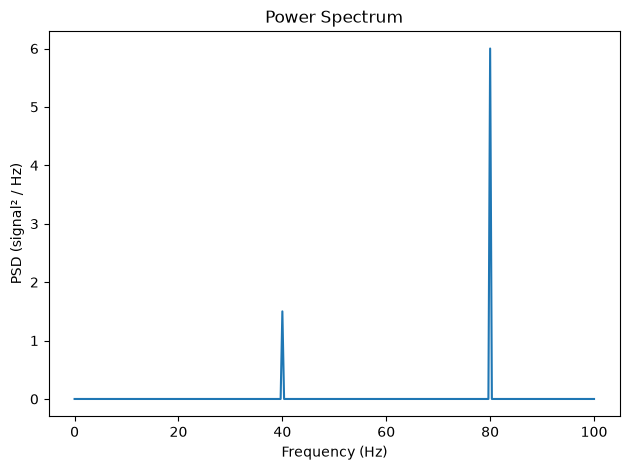

In [35]:
psd_raw, frequencies_raw, df_raw = spectral.power(signal, time_step)

utils.plot_power_spectrum(psd_raw, frequencies_raw)

Run the cell below to calculate the exact ratio between the height of each peak in the power spectrum. How does the height of each peak relate to the amplitude of each sine? Why is the ratio between the peaks in the power spectrum not 2 even though the ratio between the signal amplitudes is 2? You can write your answer as a comment in the cell below.

In [36]:
psd, frequencies, delta_freq = spectral.power(signal, time_step)
mask = (frequencies == 40) | (frequencies == 80)
print(f"Ratio between power spectrum peak at {frequency1} Hz and peak at {frequency2} Hz: {(psd[mask][1] / psd[mask][0]):.1f}")

Ratio between power spectrum peak at 40.0 Hz and peak at 80.0 Hz: 4.0


## Time-Varying Signals and the Wavelet Transform

The Fourier transform assumes that the frequency content of a signal is stationary over the entire recording window. When a signal's dominant frequency changes over time, such as an LFP that transitions from a slow oscillation during baseline to high-frequency gamma activity after stimulus onset, the Fourier spectrum smears these components and loses temporal information. The resulting spectrum shows power spread broadly across frequencies rather than two clean peaks.

The wavelet transform avoids this limitation by convolving the signal with a short, frequency-tuned basis function called a wavelet at every time point. The result is a complex-valued matrix of shape (n_frequency_bands, n_time): its squared modulus gives the instantaneous power at each frequency and time. The Morlet wavelet used here is a cosine modulated by a Gaussian window. The `bandwidth` parameter controls the Gaussian width in frequency units: larger values give better frequency resolution at the cost of broader temporal smearing.

The function `spectral.wavelet_transform_morlet(data, n_bands, freq_min, freq_max, dt, bandwidth)` returns the complex spectrum, a time axis, a frequency axis, and the cone-of-influence array. For a 1D input, the spectrum has shape (n_bands, n_time). For a 2D input of shape (n_trials, n_time), the spectrum has shape (n_trials, n_bands, n_time).

| Code | Description |
| --- | --- |
| `W, time_wavelet, frequencies_wavelet, t_coi = spectral.wavelet_transform_morlet(signal, n_bands=100, freq_min=3.0, freq_max=20.0, dt=time_step, bandwidth=1.5)` | Compute Wavelet transform over time period `time_wavelet` for frequencies `frequencies_wavelet` |
| `np.abs(W) ** 2` | Get the instantaneous power (the amplitude) of the Wavelet transform. |
| `spectral.wavelet_dsignal_show(np.abs(W) ** 2, time_vec, frequencies_wavelet)` | Plot wavelet spectrogram |

---

Run the cell below to create a signal whose frequency jumps from 5 Hz to 15 Hz at the midpoint.

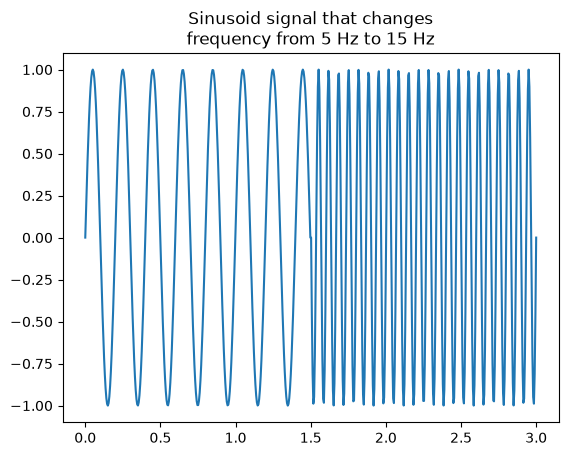

In [15]:
t0 = 0.0; t1 = 3.0; time_step = 0.005
n_bins = int(np.ceil((t1-t0)/time_step))

time_vecA = np.linspace(t0, t1/2,int(n_bins/2))
frequencyA = 5 # Hz
sineA = np.sin(2*np.pi*frequencyA*time_vecA)

time_vecB = np.linspace(t1/2, t1, int(n_bins/2))
frequencyB = 15 # Hz
sineB = np.sin(2*np.pi*frequencyB*time_vecB)

time_vec = np.linspace(t0, t1, n_bins)
signal = np.concatenate([sineA,sineB])

plt.figure()
plt.plot(time_vec,signal)
plt.title(f'Sinusoid signal that changes\nfrequency from {frequencyA} Hz to {frequencyB} Hz');

**Example**: Compute the morlet wavelet transform for the signal generated above using `spectral.wavelet_transform_morlet`.

In [16]:
W, time_wavelet, frequency_wavelet, t_coi = spectral.wavelet_transform_morlet(signal, n_bands=100, freq_min=3.0, freq_max=20.0, dt=time_step, bandwidth=1.5)

Plot the morlet wavelet spectrum.

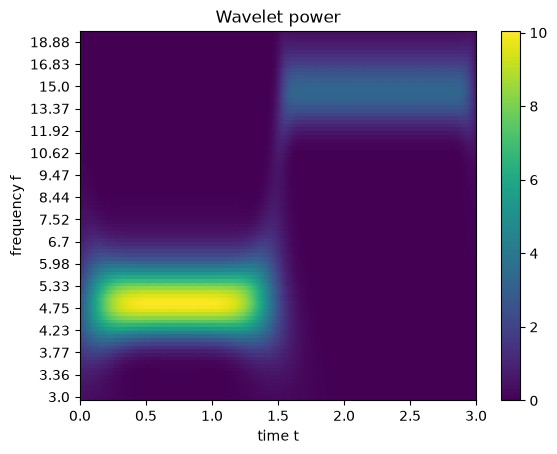

In [17]:
plt.figure()
spectral.wavelet_dsignal_show(np.abs(W) ** 2, time_vec, frequency_wavelet)
plt.title('Wavelet power');

Run the cell below to create a chirp signal whose frequency *decreases* linearly from 10 Hz to 2.0 Hz over 3 s.

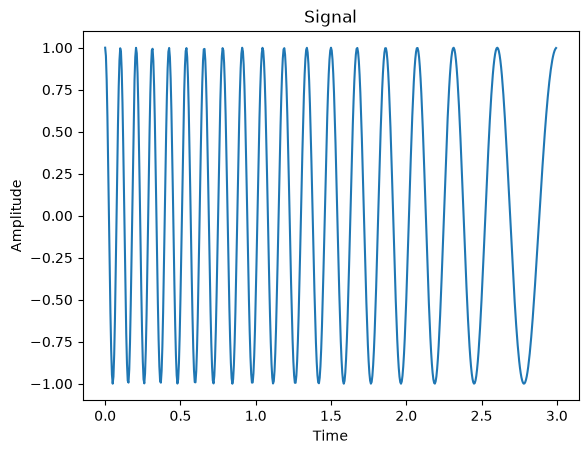

In [18]:
time_vec = np.arange(t0, t1, time_step)
f_max = 10.0; f_min = 2.0

chirp_decreasing = scipy.signal.chirp(time_vec, f0=f_max, f1=f_min, t1=t1, method='linear')
utils.plot_signal(chirp_decreasing, time_vec)

**Exercise**: Compute the morlet wavelet transform using `spectral.wavelet_transform_morlet`.

Plot the morlet wavelet spectrum.

Run the cell below to create a chirp signal whose frequency *increases* linearly from 2.0 Hz to 10.0 Hz over 3 s (the reverse of the chirp signal in the previous exercise).

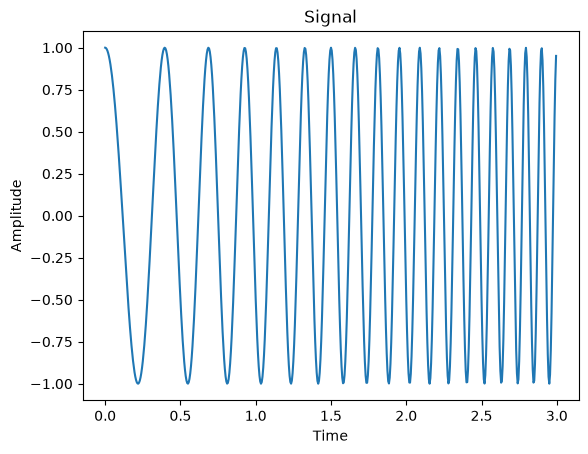

In [19]:
time_vec = np.arange(t0, t1, time_step)
f_max = 10.0; f_min = 2.0

chirp_rising = scipy.signal.chirp(time_vec, f0=f_min, f1=f_max, t1=t1, method='linear')
utils.plot_signal(chirp_rising, time_vec)

**Exercise**: Compute and plot the wavelet transform of the chirp signal generated above. Verify that the diagonal track in the spectrogram is rising for this signal.

**Exercise**: Recompute the wavelet of the rising chirp with `bandwidth=4.0`. Compare the frequency resolution and temporal sharpness with the `bandwidth=1.5` result. Which value gives a higher frequency resolution of the chirp?

Run the cell below to create a chirp signal whose frequency *increases* linearly with Gaussian noise added to the signal.

In [20]:
rng = np.random.default_rng(0)

time_vec = np.arange(t0, t1, time_step)
f_max = 10.0; f_min = 2.0

chirp_rising = scipy.signal.chirp(time_vec, f0=f_min, f1=f_max, t1=t1, method='linear') + 0.5*rng.normal(0, 5.0, n_bins)

**Exercise**: Add strong noise (`rng.normal(0, 5.0, n_bins)`) to the original chirp and recompute the wavelet transform. Is the time-varying frequency track still visible in the wavelet despite the noise?

## The Cone of Influence and LFP Spectrograms
o
Near the edges of a finite recording, the wavelet extends beyond the available data and will be convolved with zeros. This can lead to artifacts near the edges of the spectrum. The parts of the spectrum that may be affected by these edge-artifacts are referred to as the "cone of influence" (COI). You can visualize the COI to determine which parts of the spectrum this applies to by plotting the COI on top of the spectrogram. The borders of the COI are calculated with the following formula:

$$t_{COI} = \frac{n\sigma}{2\pi}\frac{\sqrt{2}}{f}$$

where $\sigma$ is the bandwidth of the Morlet wavelet, n is a parameter setting how restrictive the COI should be (3 is used as the default in the `spectral` module here), and $f$ is the frequency(ies) for which the spectrum is calculated.

The function `spectral.wavelet_dsignal_show` accepts an optional `t_coi` argument returned by `wavelet_transform_morlet`. When provided, it overlays two white lines marking the left and right COI boundaries. Results outside the COI boundary (closer to the edges) should be interpreted with caution.

| Code | Description |
| --- | --- |
| `spectral.wavelet_dsignal_show(np.abs(W) ** 2, time_vec, frequencies_wavelet, t_coi=t_coi)` | Plot Wavelet spectrogram with cone of influence |
| `W_lfp * frequencies_wavelet[:, np.newaxis]` | Weight coefficients by frequency to flatten the 1/f background |

---

Run the cell below to create a chirp signal whose frequency *decreases* linearly from 40 Hz to 4.0 Hz over 3 s.

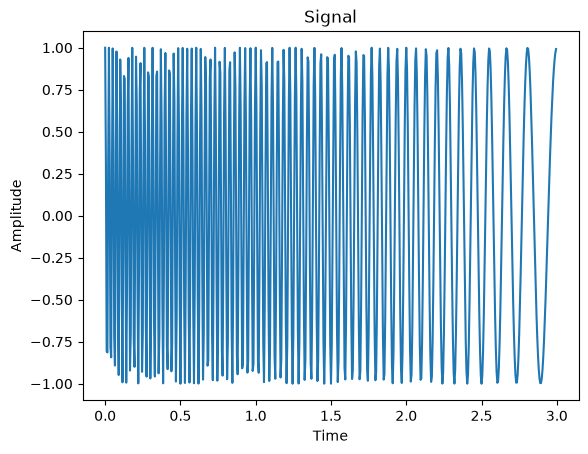

In [21]:
t0 = 0.0; t1 = 3.0; time_step = 0.005
time_vec = np.arange(t0, t1, time_step)
f_max = 40.0; f_min = 4.0

chirp_decreasing = scipy.signal.chirp(time_vec, f0=f_max, f1=f_min, t1=t1, method='linear')
utils.plot_signal(chirp_decreasing, time_vec)

**Example**: Compute the wavelet of the descending chirp and display it with the cone of influence and a frequency axis. Which frequencies and time periods (approximately) of the signal can't you trust?

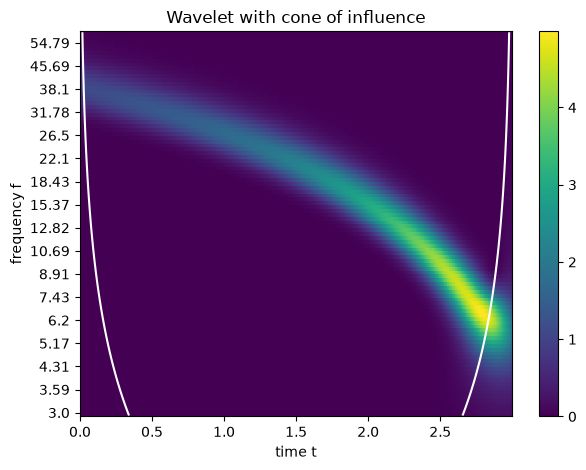

In [22]:
W, time_wavelet, frequencies_wavelet, t_coi = spectral.wavelet_transform_morlet(chirp_decreasing, n_bands=100, freq_min=3.0, freq_max=60.0, dt=time_step, bandwidth=1.5)
spectral.wavelet_dsignal_show(np.abs(W) ** 2, time_vec, frequencies_wavelet, t_coi=t_coi)
plt.title('Wavelet with cone of influence')
plt.tight_layout()

Run the cell below to create a chirp signal whose frequency *decreases* linearly from 10 Hz to 2.0 Hz over 3 s with Gaussian noise added to the signal.

In [23]:
rng = np.random.default_rng(1)
t0 = 0.0; t1 = 3.0; time_step = 0.005
n_bins = int(np.ceil((t1-t0)/time_step))
chirp_noisy = chirp_decreasing + 0.5*rng.normal(0, 3.0, n_bins)

**Exercise**: Plot the noisy chirp with the COI. Does the COI help isolate the artifact-free region from the noisy edges?

Run the cell below to load the LFP dataset.

In [24]:
data = scipy.io.loadmat('../data/spectral_dataset.mat')
v1_lfp = data['V1_lfp']
time_step_lfp = 1e-3
n_trials, n_time, n_cells = v1_lfp.shape
time_lfp = time_step_lfp * np.arange(n_time)
print(f'V1 LFP shape: {v1_lfp.shape} — (trials, time, channels)')

V1 LFP shape: (100, 1500, 100) — (trials, time, channels)


**Example**: Compute and plot the wavelet spectrogram for the first trial and 22nd channel of the LFP. Is there a prominent blob in the spectrum? Is it inside or outside the COI?

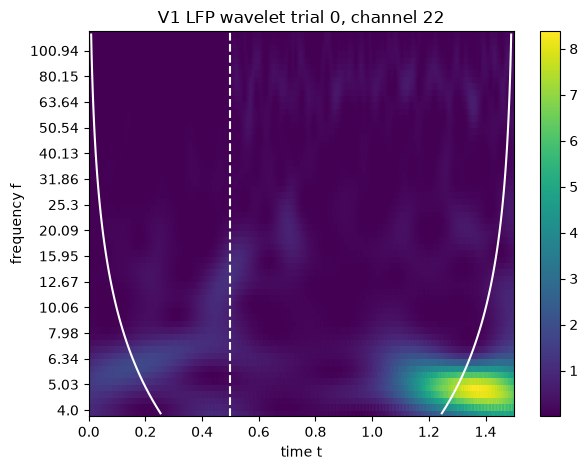

In [25]:
itrial = 0; ichan = 22
lfp_single_chan = v1_lfp[itrial, :, ichan]
W_lfp, time_wavelet, frequencies_wavelet, coi_lfp = spectral.wavelet_transform_morlet(lfp_single_chan, n_bands=60, freq_min=4.0, freq_max=120.0, dt=time_step_lfp, bandwidth=1.5)
spectral.wavelet_dsignal_show(np.abs(W_lfp) ** 2, time_lfp, frequencies_wavelet, t_coi=coi_lfp)
plt.axvline(0.5, color='white', ls='--', label='stimulus onset')
plt.title(f'V1 LFP wavelet trial {itrial}, channel {ichan}')
plt.tight_layout()
# There is a prominent blob at 1.4 seconds but it is mostly outside the COI border, so it should be interpreted with caution. It's best to calculate the spectrum for a larger time window so that the spectrum at 1.4 seconds is inside the COI

**Exercise**: Physiological signals often have a 1/f background. Normalize the wavelet spectrum by enhancing the amplitude of the wavelet coefficients proportionally to frequency. Do you see a response to the stimulus at the higher frequencies of the spectrum now? If so, are they inside or outside the COI?

**Exercise**: Average the wavelet power over all trials for channel 22. Compute the trial-averaged wavelet power by passing the full `v1_lfp[:, :, 22]` array to `wavelet_transform_morlet` and then use `spectral.wavelet_dsignal_show` (it averages over trials automatically) to plot the trial-averaged spectrum.